In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../data/credit_risk_dataset.csv')

In [ ]:
print('='*79)
print("Overview Of Data_Set")
print('='*79)
print(f"Shape Of Data_set :{df.shape}\n")
print(f"Rows in data_set :{df.shape[0]}\n")
print(f"Columns in data_set:{df.shape[1]}\n")
print(f"Name Of Columns :{df.columns}\n")

In [ ]:
print('='*79)
print("Data Assessing")
print('='*79)
# basic state
print("basic state: ")
print(df.describe().T)

In [ ]:
print("missing values: ")
print(df.isna().sum())
# Duplicates
print("Duplicates: ")
print(df.duplicated().sum())

In [ ]:

sns.heatmap(df.isnull())

In [ ]:
print("Info:")
print(df.info())

In [3]:
# Auto-separate
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()


In [4]:
num_cols=['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length']
cat_cols=['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

## distribution of data 

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df['person_age'])
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df['person_income'])
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df['person_emp_length'])
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df['loan_amnt'])
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df['loan_amnt'])
plt.show()

In [ ]:
 
plt.figure(figsize=(10,8))
sns.histplot(df['loan_int_rate'])
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df['loan_percent_income'])
plt.show()

## catrgorical_distribution

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(df['person_home_ownership'])
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(df['loan_intent'])
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(df['loan_grade'])
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(df['cb_person_default_on_file'])
plt.show()

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status',data=df)
plt.show()

## geting outliers in numeric columns

In [ ]:
for  col in num_cols:
    plt.figure(figsize=(5,5))
    sns.boxplot(df[col])
    plt.show()

## correlation of columns

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
numeric_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f'{col} vs Loan Status')
    plt.show()

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue='loan_status', kde=True, bins=30)
    plt.title(f'{col} Distribution by Loan Status')
    plt.show()

In [ ]:

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='loan_status')
    plt.title(f'{col} by Loan Status')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
corr_with_target = df[num_cols + ['loan_status']].corr()['loan_status'].sort_values(key=abs, ascending=False)
print(corr_with_target)

## Data validation & Cleanning

In [5]:
# remove duplicates
df.drop_duplicates(inplace=True)

In [6]:
df=df[(df['person_age']>18) & (df['person_age']<100)]
# 
df=df[(df['person_emp_length']<=df['person_age'])&(df['person_emp_length']<=60)]

In [7]:
x=df.drop(columns=['loan_status'])
y=df['loan_status']

In [ ]:
x

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0.10,N,26


In [ ]:
x.columns()

In [9]:
x['loan_grade'].value_counts()

loan_grade
A    10300
B    10121
C     6301
D     3549
E      951
F      236
G       64
Name: count, dtype: int64

In [22]:
x['person_home_ownership'].value_counts()

person_home_ownership
RENT        16007
MORTGAGE    13018
OWN          2391
OTHER         106
Name: count, dtype: int64

In [23]:
x['loan_intent'].value_counts()

loan_intent
EDUCATION            6246
MEDICAL              5869
VENTURE              5518
PERSONAL             5346
DEBTCONSOLIDATION    5044
HOMEIMPROVEMENT      3499
Name: count, dtype: int64

In [ ]:
x['cb_person_default_on_file'].value_counts()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, recall_score, accuracy_score,precision_score, f1_score, roc_auc_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
 


## Train_Test

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
num_pip=Pipeline([('imute',SimpleImputer()),('std',StandardScaler())])
cat_pip=Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(handle_unknown='ignore',drop='first'))])
preprocessing=ColumnTransformer([('num',num_pip,num_cols),('cat',cat_pip,cat_cols)],remainder='passthrough')

## logistice regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

# === Pipeline ===
lr_pip = Pipeline([
    ('pre', preprocessing),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# === Parameter Grid ===
param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['saga'],
    'lr__class_weight': [None, 'balanced']
}

# === GridSearchCV ===
grid_lr = GridSearchCV(
    lr_pip, param_grid_lr,
    cv=5, scoring='recall', n_jobs=-1, verbose=1
)
grid_lr.fit(x_train, y_train)

# === Best Model ===
print("Best Params:", grid_lr.best_params_)
print("Best CV Recall:", grid_lr.best_score_)

# === Test Evaluation ===
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(x_test)

print("\n=== Logistic Regression Test Results ===")
print("Recall (Default):", recall_score(y_test, y_pred_lr))
print("Precision (Default):", precision_score(y_test, y_pred_lr))
print("F1 (Default):", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, best_lr.predict_proba(x_test)[:,1]))
print("\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix (user format):\n", confusion_matrix(y_test, y_pred_lr, labels=[1, 0]))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'lr__C': 0.1, 'lr__class_weight': 'balanced', 'lr__penalty': 'l2', 'lr__solver': 'saga'}
Best CV Recall: 0.7788797061524333

=== Logistic Regression Test Results ===
Recall (Default): 0.7819383259911894
Precision (Default): 0.5523858921161826
F1 (Default): 0.6474164133738601
ROC-AUC: 0.8745660886529344

               precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.55      0.78      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.74      0.80      0.76      6305
weighted avg       0.85      0.82      0.83      6305

Confusion Matrix (user format):
 [[1065  297]
 [ 863 4080]]


In [16]:
x.iloc[0]

person_age                           21
person_income                      9600
person_home_ownership               OWN
person_emp_length                   5.0
loan_intent                   EDUCATION
loan_grade                            B
loan_amnt                          1000
loan_int_rate                     11.14
loan_percent_income                 0.1
cb_person_default_on_file             N
cb_person_cred_hist_length            2
Name: 1, dtype: object

In [21]:
best_lr.predict_proba(x.iloc[[0]])[0][1]

np.float64(0.04476660505962899)

In [12]:
#calibrate
from sklearn.calibration import CalibratedClassifierCV,calibration_curve
calibrated_model=CalibratedClassifierCV(best_lr,cv=5,method='sigmoid')
calibrated_model.fit(x_train,y_train)

,estimator,Pipeline(step...ver='saga'))])
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [21]:
uncalibrated_prob=best_lr.predict_proba(x_test)[:,1]
calibrated_prob=calibrated_model.predict_proba(x_test)[:,1]


In [22]:
actual_uncal , predi_unacl=calibration_curve(y_test,uncalibrated_prob,n_bins=10)

In [23]:
actual_cal , pred_cal=calibration_curve(y_test,calibrated_prob,n_bins=10)

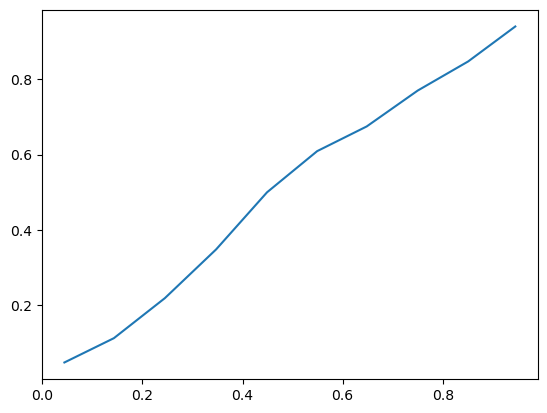

In [24]:
plt.plot(pred_cal,actual_cal)
plt.show()

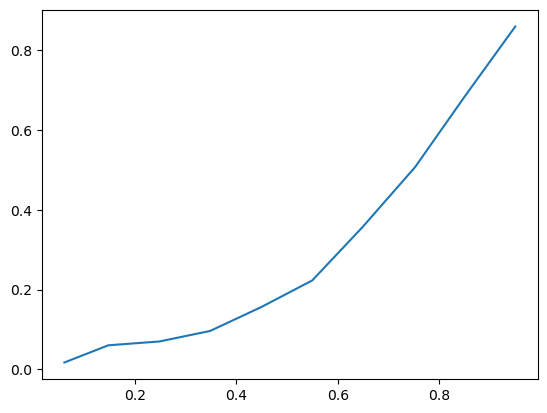

In [25]:
plt.plot(predi_unacl,actual_uncal)

In [22]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
y_proba= best_lr.predict_proba(x_test)[:,1]
results = []
for thresh in thresholds:
    y_pred_t = ( y_proba >= thresh).astype(int)
    results.append({
        'Threshold': thresh,
        'Recall': recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t)
    })
pd.DataFrame(results)

,Threshold,Recall,Precision,F1
0,0.2,0.930250,0.318742,0.474799
1,0.3,0.883994,0.392055,0.543199
2,0.4,0.837739,0.472268,0.604023
3,0.5,0.781938,0.552386,0.647416
4,0.6,0.720264,0.632495,0.673532
5,0.7,0.635830,0.704638,0.668468
6,0.8,0.507342,0.781674,0.615316


## KNN

In [14]:
from sklearn.neighbors import KNeighborsClassifier

# === Pipeline ===
knn_pip = Pipeline([
    ('pre', preprocessing),
    ('knn', KNeighborsClassifier())])

# === Parameter Grid ===
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

# === GridSearchCV ===
grid_knn = GridSearchCV(
    knn_pip, param_grid_knn,
    cv=5, scoring='recall', n_jobs=-1, verbose=1
)
grid_knn.fit(x_train, y_train)

# === Best Model ===
print("Best Params:", grid_knn.best_params_)
print("Best CV Recall:", grid_knn.best_score_)

# === Test Evaluation ===
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(x_test)

print("\n=== KNN Test Results ===")
print("Recall (Default):", recall_score(y_test, y_pred_knn))
print("Precision (Default):", precision_score(y_test, y_pred_knn))
print("F1 (Default):", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, best_knn.predict_proba(x_test)[:,1]))
print("\n", classification_report(y_test, y_pred_knn))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV Recall: 0.6303030303030304

=== KNN Test Results ===
Recall (Default): 0.6424375917767988
Precision (Default): 0.7904245709123758
F1 (Default): 0.7087889833940867
ROC-AUC: 0.858667071873395

               precision    recall  f1-score   support

           0       0.91      0.95      0.93      4943
           1       0.79      0.64      0.71      1362

    accuracy                           0.89      6305
   macro avg       0.85      0.80      0.82      6305
weighted avg       0.88      0.89      0.88      6305



In [23]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
y_proba= best_knn.predict_proba(x_test)[:,1]
results = []
for thresh in thresholds:
    y_pred_t = ( y_proba >= thresh).astype(int)
    results.append({
        'Threshold': thresh,
        'Recall': recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t)
    })
pd.DataFrame(results)

,Threshold,Recall,Precision,F1
0,0.2,0.814244,0.504779,0.623209
1,0.3,0.778267,0.559072,0.650706
2,0.4,0.662996,0.756281,0.706573
3,0.5,0.642438,0.790425,0.708789
4,0.6,0.630690,0.803555,0.706705
5,0.7,0.495595,0.902406,0.639810
6,0.8,0.436858,0.944444,0.597390


## Randomforest 

In [18]:
# === Pipeline ===
rf_pip = Pipeline([
    ('pre', preprocessing),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# === Parameter Grid ===
param_grid_rf = {
    'rf__n_estimators': [100],
    'rf__max_depth': [5, 10],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [2, 4],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__class_weight': ['balanced']  # 🔥 Imbalance ke liye
}

# === GridSearchCV ===
grid_rf = GridSearchCV(
    rf_pip, param_grid_rf,
    cv=5, scoring='recall', n_jobs=-1, verbose=1
)
grid_rf.fit(x_train, y_train)

# === Best Model ===
print("Best Params:", grid_rf.best_params_)
print("Best CV Recall:", grid_rf.best_score_)

# === Test Evaluation ===
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(x_test)

print("\n=== Random Forest Test Results ===")
print("Recall (Default):", recall_score(y_test, y_pred_rf))
print("Precision (Default):", precision_score(y_test, y_pred_rf))
print("F1 (Default):", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(x_test)[:,1]))
print("\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix (user format):\n", confusion_matrix(y_test, y_pred_rf, labels=[1, 0]))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'rf__class_weight': 'balanced', 'rf__max_depth': 5, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best CV Recall: 0.7676767676767677

=== Random Forest Test Results ===
Recall (Default): 0.7804698972099853
Precision (Default): 0.6998025016458196
F1 (Default): 0.7379382158972579
ROC-AUC: 0.9063766735201265

               precision    recall  f1-score   support

           0       0.94      0.91      0.92      4943
           1       0.70      0.78      0.74      1362

    accuracy                           0.88      6305
   macro avg       0.82      0.84      0.83      6305
weighted avg       0.89      0.88      0.88      6305

Confusion Matrix (user format):
 [[1063  299]
 [ 456 4487]]


In [14]:
rf_pip = Pipeline([
    ('pre', preprocessing),
    ('rf', RandomForestClassifier(n_estimators=100,min_samples_split=2,min_samples_leaf=2,max_features='sqrt',max_depth=5,class_weight='balanced',random_state=42, n_jobs=-1))
])

rf_pip.fit(x_train,y_train)
y_pred=rf_pip.predict(x_test)
f1_score(y_test,y_pred)

0.7379382158972579

In [15]:
import joblib 
joblib.dump(rf_pip,'../models/rf_model.pkl')

['../models/rf_model.pkl']

In [24]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
y_proba= best_rf.predict_proba(x_test)[:,1]
results = []
for thresh in thresholds:
    y_pred_t = ( y_proba >= thresh).astype(int)
    results.append({
        'Threshold': thresh,
        'Recall': recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t)
    })
pd.DataFrame(results)

,Threshold,Recall,Precision,F1
0,0.2,0.998532,0.231450,0.375794
1,0.3,0.913363,0.383595,0.540282
2,0.4,0.842878,0.532468,0.652644
3,0.5,0.780470,0.699803,0.737938
4,0.6,0.709251,0.783455,0.744509
5,0.7,0.615272,0.898178,0.730283
6,0.8,0.408957,0.985841,0.578101


## Ada Boosting

In [25]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score

# === Step 1: Base Pipeline ===

ada_pip = Pipeline([('pre', preprocessing),('ada', AdaBoostClassifier(random_state=42))])


# === Step 2: Parameter Grid ===

param_grid_ada = {
    'ada__n_estimators': [100, 200,300],
    'ada__learning_rate': [0.01, 0.1, 0.05, 0.09],
    'ada__algorithm': ['SAMME'],  # SAMME for imbalanced; SAMME.R deprecated in newer sklearn
    'ada__estimator': [DecisionTreeClassifier(max_depth=1)]  # Decision stump
}

# === Step 3: GridSearchCV (Recall Focus) ===

grid_ada = GridSearchCV(
    ada_pip,
    param_grid_ada,
    cv=5,
    scoring='recall',   # 🔥 Recall maximize karo
    n_jobs=-1,verbose=1)

grid_ada.fit(x_train, y_train)

# === Step 4: Best Model ===
print("Best Params:", grid_ada.best_params_)
print("Best CV Recall:", grid_ada.best_score_)

# === Step 5: Evaluate on Test Set ===
best_ada = grid_ada.best_estimator_
y_pred_ada = best_ada.predict(x_test)

print("\n=== AdaBoost Test Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Recall (Default):", recall_score(y_test, y_pred_ada))
print("Precision (Default):", precision_score(y_test, y_pred_ada))
print("F1 (Default):", f1_score(y_test, y_pred_ada))
print("ROC-AUC:", roc_auc_score(y_test, best_ada.predict_proba(x_test)[:,1]))
print("\n", classification_report(y_test, y_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\User\miniconda3\envs\env_ml\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best Params: {'ada__algorithm': 'SAMME', 'ada__estimator': DecisionTreeClassifier(max_depth=1), 'ada__learning_rate': 0.1, 'ada__n_estimators': 300}
Best CV Recall: 0.4692378328741965

=== AdaBoost Test Results ===
Accuracy: 0.8742268041237113
Recall (Default): 0.4911894273127753
Precision (Default): 0.8699609882964889
F1 (Default): 0.6278742374472079
ROC-AUC: 0.8948151363131476

               precision    recall  f1-score   support

           0       0.87      0.98      0.92      4943
           1       0.87      0.49      0.63      1362

    accuracy                           0.87      6305
   macro avg       0.87      0.74      0.78      6305
weighted avg       0.87      0.87      0.86      6305

Confusion Matrix:
 [[4843  100]
 [ 693  669]]


In [26]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
y_proba= best_ada.predict_proba(x_test)[:,1]
results = []
for thresh in thresholds:
    y_pred_t = ( y_proba >= thresh).astype(int)
    results.append({
        'Threshold': thresh,
        'Recall': recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t)
    })
pd.DataFrame(results)

,Threshold,Recall,Precision,F1
0,0.2,1.000000,0.223059,0.364756
1,0.3,0.900147,0.393579,0.547688
2,0.4,0.732746,0.677529,0.704056
3,0.5,0.491189,0.869961,0.627874
4,0.6,0.135095,0.953368,0.236656
5,0.7,0.055800,1.000000,0.105702
6,0.8,0.006608,1.000000,0.013129


## Gradient Boosting

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score

# === Step 1: Base Pipeline ===
gb_pip = Pipeline([
    ('pre', preprocessing),
    ('gb', GradientBoostingClassifier(random_state=42))
])

# === Step 2: Parameter Grid ===
param_grid_gb = {
    'gb__n_estimators': [100, 150],
    'gb__learning_rate': [0.01, 0.05],
    'gb__max_depth': [3, 5],
    'gb__subsample': [0.8, 1.0],
    'gb__min_samples_leaf': [1, 2, 4],
    'gb__max_features': ['sqrt', 'log2']
}

# === Step 3: GridSearchCV (Recall Focus) ===
grid_gb = GridSearchCV(
    gb_pip,
    param_grid_gb,
    cv=5,
    scoring='recall',   # 🔥 Recall maximize karo
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(x_train, y_train)

# === Step 4: Best Model ===
print("Best Params:", grid_gb.best_params_)
print("Best CV Recall:", grid_gb.best_score_)

# === Step 5: Evaluate on Test Set ===
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(x_test)

print("\n=== Gradient Boosting Test Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Recall (Default):", recall_score(y_test, y_pred_gb))
print("Precision (Default):", precision_score(y_test, y_pred_gb))
print("F1 (Default):", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, best_gb.predict_proba(x_test)[:,1]))
print("\n", classification_report(y_test, y_pred_gb))
print("Confusion Matrbbgix:\n", confusion_matrix(y_test, y_pred_gb))

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Params: {'gb__learning_rate': 0.05, 'gb__max_depth': 5, 'gb__max_features': 'sqrt', 'gb__min_samples_leaf': 2, 'gb__n_estimators': 150, 'gb__subsample': 1.0}
Best CV Recall: 0.7092745638200183

=== Gradient Boosting Test Results ===
Accuracy: 0.9337034099920698
Recall (Default): 0.7232011747430249
Precision (Default): 0.9600389863547758
F1 (Default): 0.8249581239530989
ROC-AUC: 0.9333923616155153

               precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.96      0.72      0.82      1362

    accuracy                           0.93      6305
   macro avg       0.94      0.86      0.89      6305
weighted avg       0.94      0.93      0.93      6305

Confusion Matrbbgix:
 [[4902   41]
 [ 377  985]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score

# === Pipeline ===
dt_pip = Pipeline([
    ('pre', preprocessing),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# === Parameter Grid ===
param_grid_dt = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [3, 5, 7, 10],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4, 8],
    'dt__max_features': [None, 'sqrt', 'log2'],
    'dt__class_weight': ['balanced'],  # 🔥 Imbalance handle
    'dt__ccp_alpha': [0.0, 0.001, 0.01, 0.1]  # Pruning
}


# === GridSearchCV ===
grid_dt = GridSearchCV(
    dt_pip, param_grid_dt,
    cv=5, scoring='recall', n_jobs=-1, verbose=2
)
grid_dt.fit(x_train, y_train)

# === Best Model ===
print("Best Params:", grid_dt.best_params_)
print("Best CV Recall:", grid_dt.best_score_)


# === Test Evaluation ===
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(x_test)

print("\n=== Decision Tree Test Results ===")
print("Recall (Default):", recall_score(y_test, y_pred_dt))
print("Precision (Default):", precision_score(y_test, y_pred_dt))
print("F1 (Default):", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, best_dt.predict_proba(x_test)[:,1]))
print("\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Best Params: {'dt__ccp_alpha': 0.01, 'dt__class_weight': 'balanced', 'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 2}
Best CV Recall: 0.795959595959596

=== Decision Tree Test Results ===
Recall (Default): 0.6483113069016153
Precision (Default): 0.5511860174781523
F1 (Default): 0.5958164642375169
ROC-AUC: 0.8183549438637174

               precision    recall  f1-score   support

           0       0.90      0.85      0.88      4943
           1       0.55      0.65      0.60      1362

    accuracy                           0.81      6305
   macro avg       0.72      0.75      0.74      6305
weighted avg       0.82      0.81      0.82      6305

Confusion Matrix:
 [[4224  719]
 [ 479  883]]


In [ ]:
# Best DT model ka probability nikalo
from sklearn.metrics import  precision_recall_curve,classification_report, recall_score, precision_score, f1_score, roc_auc_score

y_proba_dt = best_dt.predict_proba(x_test)[:, 1]

#Different thresholds try karo
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for thresh in thresholds:
    y_pred_thresh = (y_proba_dt >= thresh).astype(int)
    print(f"Threshold {thresh}: Recall={recall_score(y_test, y_pred_thresh):.3f}, "
          f"Precision={precision_score(y_test, y_pred_thresh):.3f}, "
          f"F1={f1_score(y_test , y_pred_thresh):.3f}")

## undersampling 

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

# === Pipeline (imblearn) ===
# ⚠️ Zaroori: imblearn.pipeline use karo, sklearn.pipeline nahi

rus_pip = ImbPipeline([
    ('pre', preprocessing),
    ('rus', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# === Fit ===
rus_pip.fit(x_train, y_train)

# === Predict ===
y_pred_rus = rus_pip.predict(x_test)

# === Evaluate ===
print("=== Random Undersampling Results ===")
print("Recall (Default):", recall_score(y_test, y_pred_rus))
print("Precision (Default):", precision_score(y_test, y_pred_rus))
print("F1 (Default):", f1_score(y_test, y_pred_rus))
print("ROC-AUC:", roc_auc_score(y_test, rus_pip.predict_proba(x_test)[:,1]))
print("\n", classification_report(y_test, y_pred_rus))
print("Confusion Matrix (user format):\n", confusion_matrix(y_test, y_pred_rus, labels=[1, 0]))

## OverSampler

In [20]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

# === Pipeline (imblearn) ===
ros_pip = ImbPipeline([
    ('pre', preprocessing),
    ('ros', RandomOverSampler(random_state=42)),
    ('model', GradientBoostingClassifier())
])

# === Fit ===
ros_pip.fit(x_train, y_train)

# === Predict ===
y_pred_ros = ros_pip.predict(x_test)

# === Evaluate ===
print("=== Random Oversampling Results ===")
print("Recall (Default):", recall_score(y_test, y_pred_ros))
print("Precision (Default):", precision_score(y_test, y_pred_ros))
print("F1 (Default):", f1_score(y_test, y_pred_ros))
print("ROC-AUC:", roc_auc_score(y_test, ros_pip.predict_proba(x_test)[:,1]))
print("\n", classification_report(y_test, y_pred_ros))
print("Confusion Matrix (user format):\n", confusion_matrix(y_test, y_pred_ros, labels=[1, 0]))

=== Random Oversampling Results ===
Recall (Default): 0.8002936857562408
Precision (Default): 0.7199471598414795
F1 (Default): 0.7579972183588317
ROC-AUC: 0.9332443453014884

               precision    recall  f1-score   support

           0       0.94      0.91      0.93      4943
           1       0.72      0.80      0.76      1362

    accuracy                           0.89      6305
   macro avg       0.83      0.86      0.84      6305
weighted avg       0.89      0.89      0.89      6305

Confusion Matrix (user format):
 [[1090  272]
 [ 424 4519]]


## SMOTE

In [34]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (classification_report, recall_score, 
                             precision_score, f1_score, roc_auc_score, confusion_matrix)

smote_pip = ImbPipeline([
    ('pre', preprocessing),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        max_depth=5,
        max_features='sqrt',
        min_samples_split=2,
        min_samples_leaf=2,
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])
smote_pip.fit(x_train, y_train)
y_pred_smote = smote_pip.predict(x_test)

# === Evaluate ===
print("=== SMOTE + RF Results ===")
print("Recall (Default):", recall_score(y_test, y_pred_smote))
print("Precision (Default):", precision_score(y_test, y_pred_smote))
print("F1 (Default):", f1_score(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, smote_pip.predict_proba(x_test)[:,1]))  # ✅ Fix
print("\n", classification_report(y_test, y_pred_smote))
print("Confusion Matrix (user format):\n", confusion_matrix(y_test, y_pred_smote, labels=[1, 0]))


=== SMOTE + RF Results ===
Recall (Default): 0.7591776798825257
Precision (Default): 0.7338537970191625
F1 (Default): 0.7463009743774811
ROC-AUC: 0.9050135568981247

               precision    recall  f1-score   support

           0       0.93      0.92      0.93      4943
           1       0.73      0.76      0.75      1362

    accuracy                           0.89      6305
   macro avg       0.83      0.84      0.84      6305
weighted avg       0.89      0.89      0.89      6305

Confusion Matrix (user format):
 [[1034  328]
 [ 375 4568]]


In [35]:
from sklearn.metrics import recall_score, precision_score, f1_score

# SMOTE + RF ki probability nikalo
y_proba_smote = smote_pip.predict_proba(x_test)[:, 1]

# Different thresholds try karo
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
results = []

for thresh in thresholds:
    y_pred_t = (y_proba_smote >= thresh).astype(int)
    results.append({
        'Threshold': thresh,
        'Recall': recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t)
    })

import pandas as pd
print(pd.DataFrame(results).round(3))

   Threshold  Recall  Precision     F1
0       0.30   0.917      0.378  0.536
1       0.35   0.867      0.471  0.610
2       0.40   0.849      0.534  0.656
3       0.45   0.792      0.666  0.724
4       0.50   0.759      0.734  0.746
5       0.55   0.709      0.766  0.737
6       0.60   0.677      0.807  0.736
